In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder

from IDS_Pipeline.utils.main_utils.utils import write_yaml_file

# -Intial EDA-

## Loading single Dataset for EDA

In [2]:
df = pd.read_csv('Friday-WorkingHours.pcap_lycos.csv')
df.head()

,flow_id,src_addr,src_port,dst_addr,dst_port,ip_prot,timestamp,flow_duration,down_up_ratio,pkt_len_max,...,bwd_bulk_bytes_mean,bwd_bulk_pkt_mean,bwd_bulk_rate_mean,fwd_subflow_bytes_mean,fwd_subflow_pkt_mean,bwd_subflow_bytes_mean,bwd_subflow_pkt_mean,fwd_tcp_init_win_bytes,bwd_tcp_init_win_bytes,label
0,192.168.10.3-192.168.10.50-3268-56108-6,192.168.10.3,3268,192.168.10.50,56108,6,1499428790315195,112740690,2.0,403.0,...,0.0,0.0,0.0,144.000000,2.000000,806.000000,4.000000,2078,377,benign
1,192.168.10.50-192.168.10.3-42144-389-6,192.168.10.50,42144,192.168.10.3,389,6,1499428790316273,112740560,0.5,403.0,...,0.0,0.0,0.0,806.000000,4.000000,632.000000,2.000000,955,2078,benign
2,192.168.10.9-224.0.0.22-0-0-2,192.168.10.9,0,224.0.0.22,0,2,1499428834843793,54760,0.0,8.0,...,0.0,0.0,0.0,32.000000,4.000000,0.000000,0.000000,-1,-1,benign
3,192.168.10.9-224.0.0.252-63210-5355-17,192.168.10.9,63210,224.0.0.252,5355,17,1499428834845380,100126,0.0,28.0,...,0.0,0.0,0.0,616.000000,22.000000,0.000000,0.000000,-1,-1,benign
4,192.168.10.9-192.168.10.3-137-137-17,192.168.10.9,137,192.168.10.3,137,17,1499428835164943,93069427,1.0,68.0,...,0.0,0.0,0.0,131.111111,2.222222,131.111111,2.222222,-1,-1,benign


### Basic Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542962 entries, 0 to 542961
Data columns (total 83 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   flow_id                 542962 non-null  object 
 1   src_addr                542962 non-null  object 
 2   src_port                542962 non-null  int64  
 3   dst_addr                542962 non-null  object 
 4   dst_port                542962 non-null  int64  
 5   ip_prot                 542962 non-null  int64  
 6   timestamp               542962 non-null  int64  
 7   flow_duration           542962 non-null  int64  
 8   down_up_ratio           542962 non-null  float64
 9   pkt_len_max             542962 non-null  float64
 10  pkt_len_min             542962 non-null  float64
 11  pkt_len_mean            542962 non-null  float64
 12  pkt_len_var             542962 non-null  float64
 13  pkt_len_std             542962 non-null  float64
 14  bytes_per_s         

In [4]:
df.describe()

,src_port,dst_port,ip_prot,timestamp,flow_duration,down_up_ratio,pkt_len_max,pkt_len_min,pkt_len_mean,pkt_len_var,...,fwd_bulk_rate_mean,bwd_bulk_bytes_mean,bwd_bulk_pkt_mean,bwd_bulk_rate_mean,fwd_subflow_bytes_mean,fwd_subflow_pkt_mean,bwd_subflow_bytes_mean,bwd_subflow_pkt_mean,fwd_tcp_init_win_bytes,bwd_tcp_init_win_bytes
count,542962.000000,542962.000000,542962.000000,5.429620e+05,5.429620e+05,542962.000000,542962.000000,542962.000000,542962.000000,5.429620e+05,...,5.429620e+05,5.429620e+05,542962.000000,5.429620e+05,542962.000000,542962.000000,5.429620e+05,542962.000000,542962.000000,542962.000000
mean,47329.304095,2759.894764,9.840136,1.499447e+15,8.122517e+06,1.088947,1588.334033,15.170905,330.905652,1.512636e+06,...,1.346116e+05,2.663350e+03,1.288817,1.269580e+06,161.612610,4.605144,9.045134e+03,5.616333,9206.506675,9693.412156
std,15810.672737,8543.048233,5.401070,7.900628e+09,2.615344e+07,0.379000,2903.036685,24.602741,540.475071,3.760201e+06,...,3.369379e+06,2.791999e+05,98.674842,6.802852e+06,1487.658488,567.884993,1.681173e+06,768.964008,12576.491398,14529.257308
min,0.000000,0.000000,1.000000,1.499429e+15,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,-1.000000,-1.000000
25%,39794.000000,53.000000,6.000000,1.499440e+15,6.900000e+01,1.000000,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000,0.000000e+00,1.000000,-1.000000,-1.000000
50%,52332.000000,80.000000,6.000000,1.499450e+15,3.077050e+04,1.000000,103.000000,0.000000,70.000000,1.323000e+03,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,39.000000,1.769231,1.520000e+02,2.000000,1024.000000,0.000000
75%,59278.750000,1038.000000,17.000000,1.499453e+15,6.177952e+05,1.000000,1460.000000,35.000000,262.679643,2.629032e+05,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,78.000000,2.750000,1.581500e+03,2.500000,8192.000000,29200.000000
max,65535.000000,65521.000000,132.000000,1.499458e+15,1.200000e+08,8.070423,24820.000000,1359.000000,2323.000000,2.686570e+07,...,4.870000e+08,1.567598e+08,58270.750000,8.726667e+08,207918.000000,207963.000000,6.113216e+08,284603.000000,65535.000000,65535.000000


In [5]:
df['label'].value_counts()

label
benign      286438
portscan    160106
ddos         95683
bot            735
Name: count, dtype: int64

#### Checking for nan and infinity value

In [27]:
## Checking for nan value
# df.loc[:,df.isna().any()]
def check_null_values(df:pd.DataFrame):
    print(df.columns[df.isna().any()].tolist())  #any() checks for atleast one true in whena condition or a particular function is applied

In [6]:
check_null_values(df)

[]


In [27]:
# df['flow_bytes/s'].isnull().sum()

In [7]:
original_col = df.columns
print(original_col)

Index(['flow_id', 'src_addr', 'src_port', 'dst_addr', 'dst_port', 'ip_prot',
       'timestamp', 'flow_duration', 'down_up_ratio', 'pkt_len_max',
       'pkt_len_min', 'pkt_len_mean', 'pkt_len_var', 'pkt_len_std',
       'bytes_per_s', 'pkt_per_s', 'fwd_pkt_per_s', 'bwd_pkt_per_s',
       'fwd_pkt_cnt', 'fwd_pkt_len_tot', 'fwd_pkt_len_max', 'fwd_pkt_len_min',
       'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'fwd_pkt_hdr_len_tot',
       'fwd_pkt_hdr_len_min', 'fwd_non_empty_pkt_cnt', 'bwd_pkt_cnt',
       'bwd_pkt_len_tot', 'bwd_pkt_len_max', 'bwd_pkt_len_min',
       'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'bwd_pkt_hdr_len_tot',
       'bwd_pkt_hdr_len_min', 'bwd_non_empty_pkt_cnt', 'iat_max', 'iat_min',
       'iat_mean', 'iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min',
       'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max',
       'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'active_max',
       'active_min', 'active_mean', 'active_std', 'idle_max', 'idle_min',
     

## Preprocessing Data

In [23]:
def preprocess_column_name(df:pd.DataFrame):
    df.columns = [col.strip().lower().replace(' ', '_').replace('(', '').replace(')', '') for col in df.columns]
    return df.columns

In [ ]:
preprocessed_col_name = preprocess_column_name(df)
preprocessed_col_name == original_col
# 'flag_SYN' -> 'flag_syn'

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

In [10]:
preprocessed_col_name

Index(['flow_id', 'src_addr', 'src_port', 'dst_addr', 'dst_port', 'ip_prot',
       'timestamp', 'flow_duration', 'down_up_ratio', 'pkt_len_max',
       'pkt_len_min', 'pkt_len_mean', 'pkt_len_var', 'pkt_len_std',
       'bytes_per_s', 'pkt_per_s', 'fwd_pkt_per_s', 'bwd_pkt_per_s',
       'fwd_pkt_cnt', 'fwd_pkt_len_tot', 'fwd_pkt_len_max', 'fwd_pkt_len_min',
       'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'fwd_pkt_hdr_len_tot',
       'fwd_pkt_hdr_len_min', 'fwd_non_empty_pkt_cnt', 'bwd_pkt_cnt',
       'bwd_pkt_len_tot', 'bwd_pkt_len_max', 'bwd_pkt_len_min',
       'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'bwd_pkt_hdr_len_tot',
       'bwd_pkt_hdr_len_min', 'bwd_non_empty_pkt_cnt', 'iat_max', 'iat_min',
       'iat_mean', 'iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min',
       'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max',
       'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'active_max',
       'active_min', 'active_mean', 'active_std', 'idle_max', 'idle_min',
     

In [11]:
df.head()

,flow_id,src_addr,src_port,dst_addr,dst_port,ip_prot,timestamp,flow_duration,down_up_ratio,pkt_len_max,...,bwd_bulk_bytes_mean,bwd_bulk_pkt_mean,bwd_bulk_rate_mean,fwd_subflow_bytes_mean,fwd_subflow_pkt_mean,bwd_subflow_bytes_mean,bwd_subflow_pkt_mean,fwd_tcp_init_win_bytes,bwd_tcp_init_win_bytes,label
0,192.168.10.3-192.168.10.50-3268-56108-6,192.168.10.3,3268,192.168.10.50,56108,6,1499428790315195,112740690,2.0,403.0,...,0.0,0.0,0.0,144.000000,2.000000,806.000000,4.000000,2078,377,benign
1,192.168.10.50-192.168.10.3-42144-389-6,192.168.10.50,42144,192.168.10.3,389,6,1499428790316273,112740560,0.5,403.0,...,0.0,0.0,0.0,806.000000,4.000000,632.000000,2.000000,955,2078,benign
2,192.168.10.9-224.0.0.22-0-0-2,192.168.10.9,0,224.0.0.22,0,2,1499428834843793,54760,0.0,8.0,...,0.0,0.0,0.0,32.000000,4.000000,0.000000,0.000000,-1,-1,benign
3,192.168.10.9-224.0.0.252-63210-5355-17,192.168.10.9,63210,224.0.0.252,5355,17,1499428834845380,100126,0.0,28.0,...,0.0,0.0,0.0,616.000000,22.000000,0.000000,0.000000,-1,-1,benign
4,192.168.10.9-192.168.10.3-137-137-17,192.168.10.9,137,192.168.10.3,137,17,1499428835164943,93069427,1.0,68.0,...,0.0,0.0,0.0,131.111111,2.222222,131.111111,2.222222,-1,-1,benign


In [12]:
## Checking for infinite values
def check_inf_values(df:pd.DataFrame):
    num_columns = df.select_dtypes(include = np.number).columns
    has_infinite = np.isinf(df[num_columns]).sum()
    print(has_infinite[has_infinite > 0])   # pandas always keeps column name along with it, to use it as a label
    # df.loc[:,df.isin([np.nan, np.inf, -np.inf]).any()].sum()

    infinite_col = (has_infinite[has_infinite > 0]).keys()
    print(df[infinite_col])

In [13]:
check_inf_values(df)

Series([], dtype: int64)
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[542962 rows x 0 columns]


In [14]:
categorical_col = (df.select_dtypes(include=['object'])).columns
numerical_col = df.select_dtypes(include=['number']).columns
print(categorical_col,len(categorical_col))
print(numerical_col,len(numerical_col))

Index(['flow_id', 'src_addr', 'dst_addr', 'label'], dtype='object') 4
Index(['src_port', 'dst_port', 'ip_prot', 'timestamp', 'flow_duration',
       'down_up_ratio', 'pkt_len_max', 'pkt_len_min', 'pkt_len_mean',
       'pkt_len_var', 'pkt_len_std', 'bytes_per_s', 'pkt_per_s',
       'fwd_pkt_per_s', 'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_len_tot',
       'fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean',
       'fwd_pkt_len_std', 'fwd_pkt_hdr_len_tot', 'fwd_pkt_hdr_len_min',
       'fwd_non_empty_pkt_cnt', 'bwd_pkt_cnt', 'bwd_pkt_len_tot',
       'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean',
       'bwd_pkt_len_std', 'bwd_pkt_hdr_len_tot', 'bwd_pkt_hdr_len_min',
       'bwd_non_empty_pkt_cnt', 'iat_max', 'iat_min', 'iat_mean', 'iat_std',
       'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min', 'fwd_iat_mean',
       'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max', 'bwd_iat_min',
       'bwd_iat_mean', 'bwd_iat_std', 'active_max', 'active_min',
       'active_mean', 'active_

### We will drop columns that can lead our model to become biased and memorize data instead of learning patterns. This columns are:
1. src_addr and dst_addr: During a attack , a specific source floods a large number of packets to a particular destination address. Large no. of specfic src_addr and dst_addr, will lead to model being biased on the address during training and give a higher train accuracy. But in live production it will fail, this because model memorize the data, and not the pattern in data
2. timestamp: During creation of dataset, the attack were conducted during particular time period, model will memorize the timestamp were most no. of attack is happening
3. Flow Id: No use

In [13]:
def drop_col(df:pd.DataFrame):
    col_to_drop = ['flow_id', 'src_addr', 'dst_addr','timestamp','day']
    df.drop(columns=col_to_drop,inplace=True)
    return df

In [16]:
df = drop_col(df)

In [14]:
# print(df.columns)
le = LabelEncoder()
def label_encoding(df:pd.DataFrame):
    df['label_encoded'] = le.fit_transform(df['label'])
    df['label_encoded'].value_counts()
    df = df.drop(columns='label',axis=1)
    return df

In [18]:
copy_df = label_encoding(df)
copy_df.head()

,src_port,dst_port,ip_prot,flow_duration,down_up_ratio,pkt_len_max,pkt_len_min,pkt_len_mean,pkt_len_var,pkt_len_std,...,bwd_bulk_bytes_mean,bwd_bulk_pkt_mean,bwd_bulk_rate_mean,fwd_subflow_bytes_mean,fwd_subflow_pkt_mean,bwd_subflow_bytes_mean,bwd_subflow_pkt_mean,fwd_tcp_init_win_bytes,bwd_tcp_init_win_bytes,label_encoded
0,3268,56108,6,112740690,2.0,403.0,0.0,158.333333,31450.099291,177.341758,...,0.0,0.0,0.0,144.000000,2.000000,806.000000,4.000000,2078,377,0
1,42144,389,6,112740560,0.5,403.0,0.0,239.666667,30619.460993,174.984174,...,0.0,0.0,0.0,806.000000,4.000000,632.000000,2.000000,955,2078,0
2,0,0,2,54760,0.0,8.0,8.0,8.000000,0.000000,0.000000,...,0.0,0.0,0.0,32.000000,4.000000,0.000000,0.000000,-1,-1,0
3,63210,5355,17,100126,0.0,28.0,28.0,28.000000,0.000000,0.000000,...,0.0,0.0,0.0,616.000000,22.000000,0.000000,0.000000,-1,-1,0
4,137,137,17,93069427,1.0,68.0,50.0,59.000000,46.153846,6.793662,...,0.0,0.0,0.0,131.111111,2.222222,131.111111,2.222222,-1,-1,0


In [15]:
## plotting heatmap
def plot_heatmap(df:pd.DataFrame):
    corr_matrix_func = df.corr()
    plt.figure(figsize=(20, 20))
    sns.heatmap(corr_matrix_func, annot=False, cmap='coolwarm', center=0, linewidth = 0.5)
    plt.title('Feature Correlation Heatmap')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()
    return corr_matrix_func

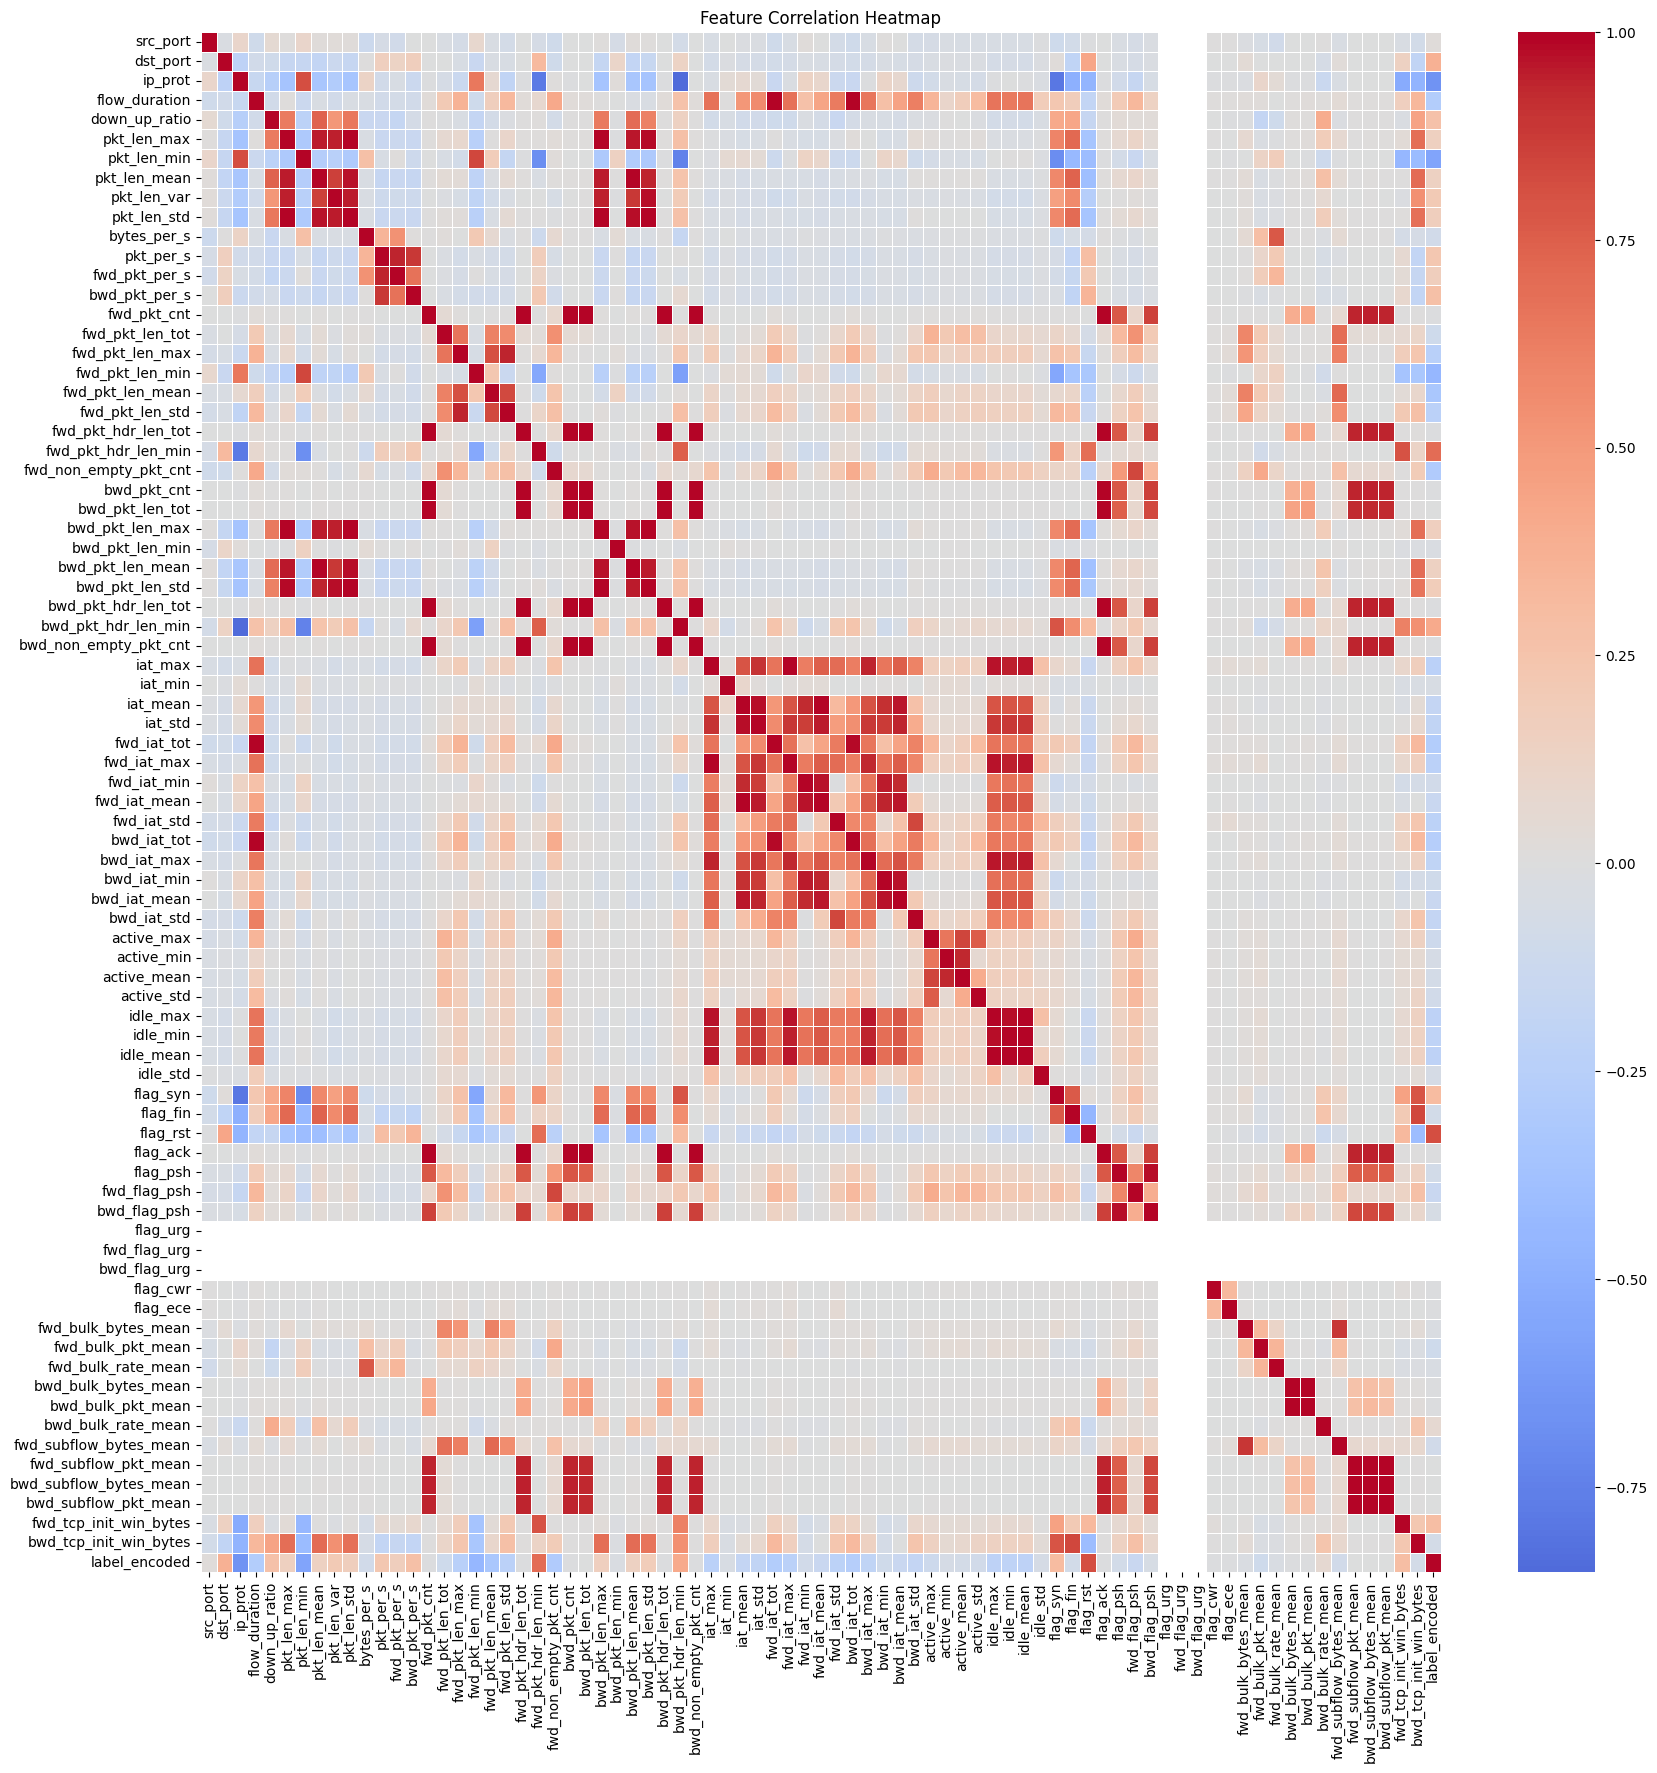

In [20]:
corr_matrix = plot_heatmap(copy_df)

In [16]:
## Seeing highly correlated 

def drop_highly_correlated_col(corr_matrix, threshold=0.93):
    # Find coordinates of all values above the threshold
    high_corr = np.where(np.abs(corr_matrix) > threshold)
    
    # Use a set comprehension to grab ONLY the column names (y-axis)
    # The 'if x != y and x < y' keeps only the upper triangle
    cols_to_drop = {
        corr_matrix.columns[y] 
        for x, y in zip(*high_corr) 
        if x != y and x < y
    }
    
    # Convert back to a list so it can be passed directly into df.drop()
    return list(cols_to_drop)

In [23]:
high_corr_col_df = drop_highly_correlated_col(corr_matrix)
len(high_corr_col_df)

31

In [24]:
df = df.drop(columns=high_corr_col_df)
df.shape

(542962, 49)

In [27]:
df.drop(columns=['label_encoded'],inplace=True)

In [31]:
df['label'].value_counts()

label
benign      286438
portscan    160106
ddos         95683
bot            735
Name: count, dtype: int64

## Handling infinity value

In [ ]:
df['label'] = le.inverse_transform(df['label_encoded']) #
df.drop(columns=['label_encoded'],inplace=True) #

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(numeric_features,'\n',categorical_features)

# Prepare the data
X = df[numeric_features]
y = df['label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


def replace_infinity(X):
    # np.isinf() catches both positive and negative infinity safely
    return np.where(np.isinf(X), np.nan, X)

inf_to_nan_transformer = FunctionTransformer(replace_infinity)    # To put custom Pandas/NumPy function into a Scikit-Learn pipeline, we wrap it in FunctionTransformer.

transformer = ColumnTransformer(
    transformers=[
        # (Name, Transformer Object, List of Columns)
        ("inf_to_nan", inf_to_nan_transformer, infinite_col)
    ],
    remainder='passthrough' # This tells it not to delete your other columns
)

transformer.set_output(transform="pandas")

X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytes/s', 'flow_packets/s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length', 'bwd_header_length', 'fwd_packets/s', 'bwd_packets/s', 'min_packet_length', 'max_packet_length', 'packet_length_mean', 'packet_length_std', 'packet_length_variance', 'fin_flag_count', 'syn_flag_count', 'rst_flag_count', 'psh_flag_count', 'ack_flag_count', 'urg_flag_count', 'cwe_flag_count', 'ece_flag_count

c:\Users\priyanshu\anaconda3\envs\venv\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:305: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))
c:\Users\priyanshu\anaconda3\envs\venv\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:305: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))


## Seeing Important Features

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score

def important_features(df:pd.DataFrame):
    
    numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()
    print(numeric_features,'\n',categorical_features)

    # Prepare the data
    X = df[numeric_features]
    y = df['label']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    # Hyperparameter settings
    hyperparameters = {
        'n_estimators': 150,    # Number of trees
        'max_depth': 30,        # Limit tree depth
        'random_state': 42,     # For reproducibility
        'n_jobs': -1            # Use all available cores
    }


    # Create the Random Forest model with specified hyperparameters
    rf = RandomForestClassifier(**hyperparameters)

    # Fit the model on the training set
    rf.fit(X_train, y_train)

    # Cross-validation on the training set
    # cv_scores = cross_val_score(rf, X_train, y_train, cv=5, n_jobs=-1)
    # print(f'Cross-Validation Score: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')



    # Predict on test set
    y_pred = rf.predict(X_test)

    # Feature importances
    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': numeric_features, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

    # Confusion matrix
    rf_labels = rf.classes_
    cm = confusion_matrix(y_test, y_pred)

    print(f"train f1 scor: {f1_score(y_train,rf.predict(X_train),average='macro')}")
    # Calculate test scores
    # rf_labels = le.inverse_transform(rf.classes_)
    report = classification_report(y_test, y_pred, target_names=rf_labels)
    print("\nClassification Report:\n")
    print(report, end='\n\n')

    # Plot feature importances
    plt.figure(figsize=(18, 12))
    plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.title('Feature Importance from Random Forest')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


    print(cm, rf_labels)
    return feature_importance_df,rf

['src_port', 'dst_port', 'ip_prot', 'flow_duration', 'down_up_ratio', 'pkt_len_max', 'pkt_len_min', 'bytes_per_s', 'pkt_per_s', 'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_len_tot', 'fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_hdr_len_min', 'fwd_non_empty_pkt_cnt', 'bwd_pkt_len_min', 'bwd_pkt_hdr_len_min', 'iat_max', 'iat_min', 'iat_mean', 'fwd_iat_min', 'fwd_iat_std', 'bwd_iat_std', 'active_max', 'active_min', 'active_std', 'idle_std', 'flag_syn', 'flag_fin', 'flag_rst', 'flag_psh', 'fwd_flag_psh', 'flag_urg', 'fwd_flag_urg', 'bwd_flag_urg', 'flag_cwr', 'flag_ece', 'fwd_bulk_bytes_mean', 'fwd_bulk_pkt_mean', 'fwd_bulk_rate_mean', 'bwd_bulk_bytes_mean', 'bwd_bulk_rate_mean', 'fwd_subflow_bytes_mean', 'fwd_tcp_init_win_bytes', 'bwd_tcp_init_win_bytes'] 
 ['label']

Classification Report:

              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     71610
         bot       1.00      1.00      1.00       184
        ddos       

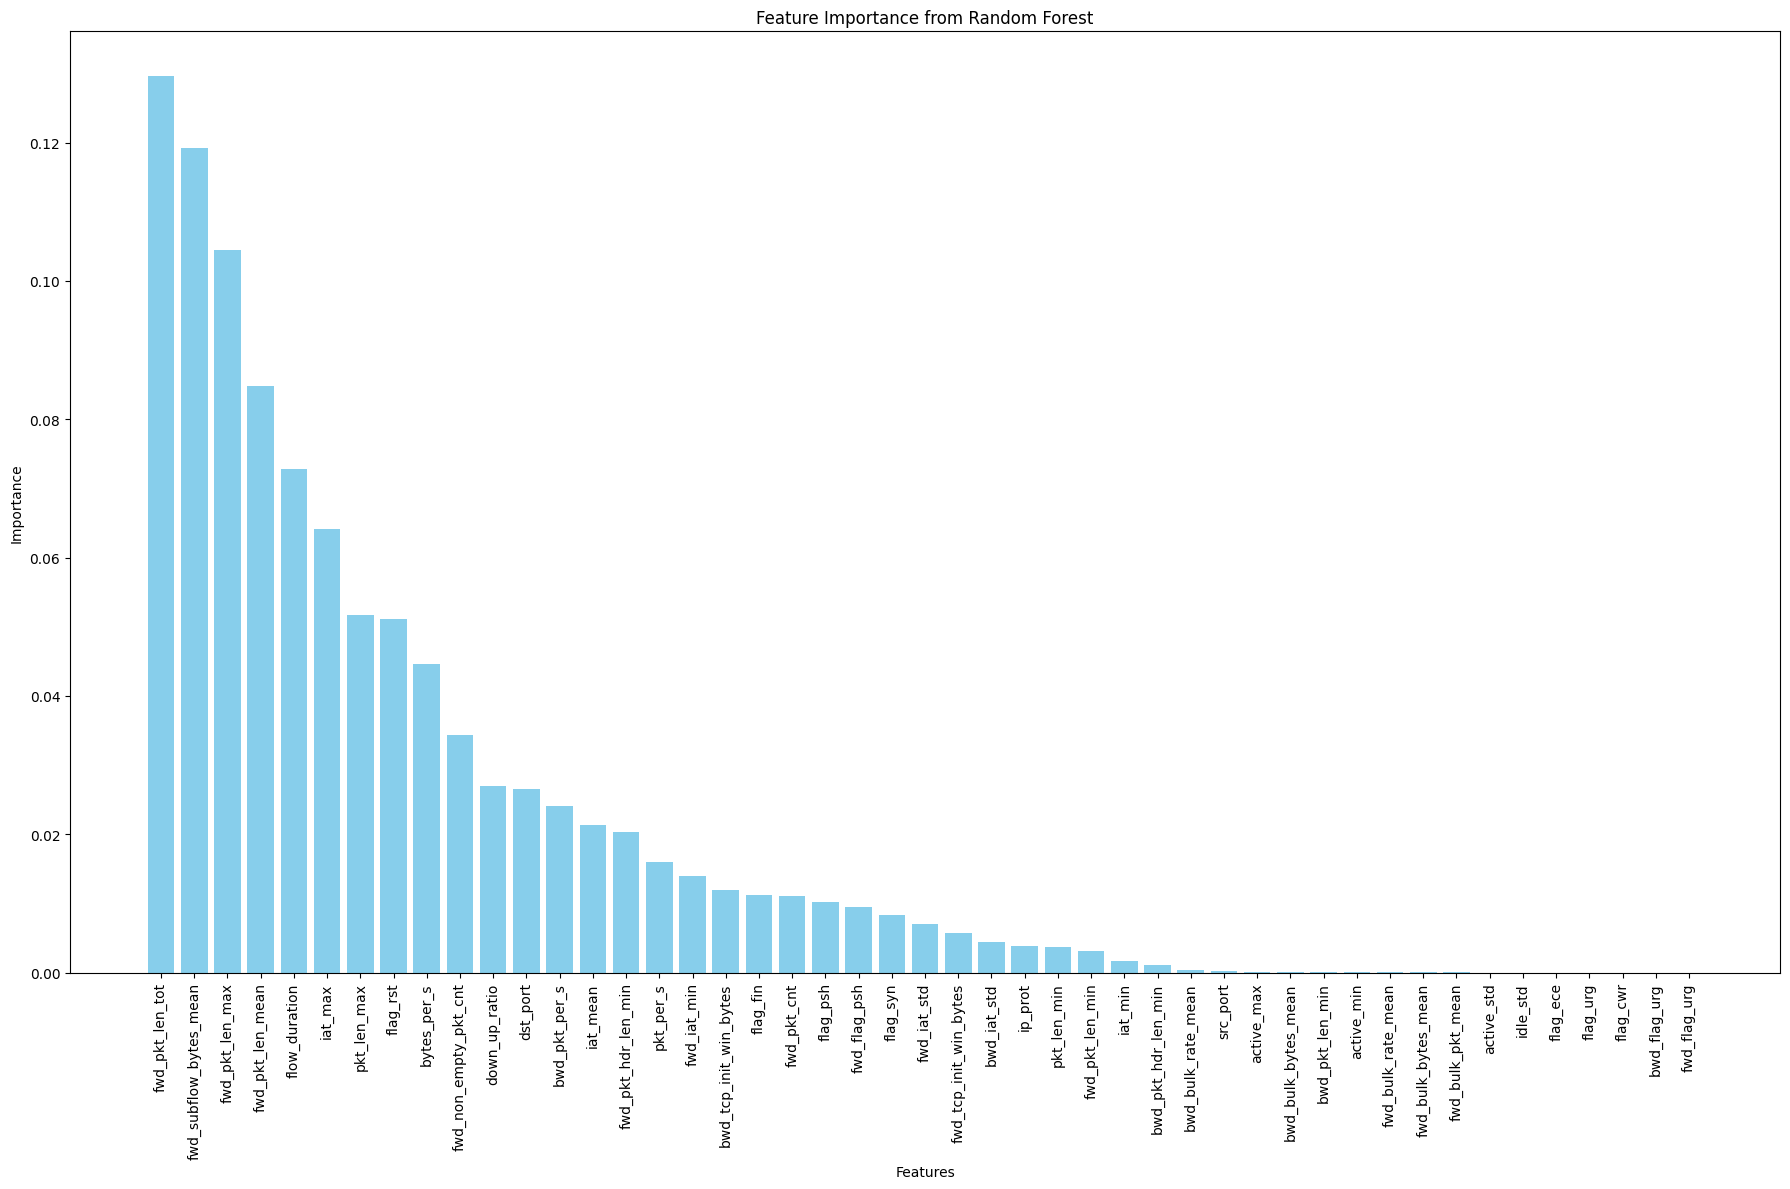

[[71610     0     0     0]
 [    0   184     0     0]
 [    0     0 23921     0]
 [    3     0     0 40023]] ['benign' 'bot' 'ddos' 'portscan']


,Feature,Importance
11,fwd_pkt_len_tot,0.129593
44,fwd_subflow_bytes_mean,0.119257
12,fwd_pkt_len_max,0.104452
14,fwd_pkt_len_mean,0.084832
3,flow_duration,0.072802
19,iat_max,0.064127
5,pkt_len_max,0.051681
31,flag_rst,0.051169
7,bytes_per_s,0.044662
16,fwd_non_empty_pkt_cnt,0.034320


In [29]:
important_features(df)

# ----Essential EDA---- 

Before we took master df and done test on that only, which may have lead to data leakage during splitting, resulting in high accuracy of RF, this time we will only conduct EDA on train dataset

In [6]:
train_df = pd.read_csv("../Artifacts/data_ingestion/ingested/train.csv")
train_df.shape

(1647204, 84)

In [7]:
# 1. Count how many times each label appears
label_counts = train_df['label'].value_counts()
print(label_counts)

label
benign                     1294871
dos_hulk                    158988
portscan                    104073
ddos                         62483
dos_goldeneye                 6765
dos_slowloris                 5674
dos_slowhttptest              4866
ftp_patator                   4003
ssh_patator                   2959
webattack_bruteforce          1360
webattack_xss                  661
bot                            478
webattack_sql_injection         12
heartbleed                      11
Name: count, dtype: int64


In [9]:
# Mapping the attacks to the new group
attack_mapping = {
    'benign': 'benign',
    'ddos': 'ddos',
    'portscan': 'portscan',
    'dos_hulk': 'dos',
    'dos_goldeneye': 'dos',
    'dos_slowloris': 'dos',
    'dos_slowhttptest': 'dos',
    'ftp_patator': 'brute_force',
    'ssh_patator': 'brute_force',
    'bot': 'bot',
    'webattack_bruteforce': 'web_attacks',
    'webattack_xss': 'web_attacks',
    'webattack_sql_injection': 'web_attacks',
    'Heartbleed': 'miscellaneous'
}

# 2. Apply it to the MASTER dataset
train_df['label'] = train_df['label'].replace(attack_mapping)
train_df['label'].value_counts()

label
benign         1294871
dos             176293
portscan        104073
ddos             62483
brute_force       6962
web_attacks       2033
bot                478
heartbleed          11
Name: count, dtype: int64

In [59]:
percentage_dict = {}
for idx, val in train_df['label'].value_counts().items():
    percentage_dict[idx] = (val/train_df.shape[0])*100 
    # print(f"Index: {idx}, Percentage: {val}")
print(percentage_dict)

{'benign': 78.61076388741331, 'dos': 10.70263168918275, 'portscan': 6.318203149236306, 'ddos': 3.7933016956725774, 'brute_force': 0.42265842557611644, 'web_attacks': 0.12342208836487285, 'bot': 0.029019064554062578}


48,22,13,7,3,3,2
total 625k
300k; 137.5k; 81,250; 43,750; 18750; 18750; 12,500

In [10]:
# 2. Find the labels that have at least 2 instances
label_counts = train_df['label'].value_counts()
valid_labels = label_counts[label_counts >= 15].index
print(valid_labels)

# 3. Filter the master dataset to only keep those valid labels
train_df = train_df[train_df['label'].isin(valid_labels)]

print(f"Removed rare classes. New shape: {train_df.shape}")

Index(['benign', 'dos', 'portscan', 'ddos', 'brute_force', 'web_attacks',
       'bot'],
      dtype='object', name='label')
Removed rare classes. New shape: (1647193, 84)


In [18]:
drop_col(train_df)
train_df.shape

(1647193, 79)

In [19]:
#Taking 10% of our master dataset, as processing 2.8M rows at every runs is computationally heavy(In CIC-IDS2017 dataset)
#Here will take 25%

eda_sample, _ = train_test_split(train_df, train_size=0.4, stratify=train_df['label'], random_state=42)
eda_sample.shape

(658877, 79)

In [20]:
eda_sample.columns

Index(['src_port', 'dst_port', 'ip_prot', 'flow_duration', 'down_up_ratio',
       'pkt_len_max', 'pkt_len_min', 'pkt_len_mean', 'pkt_len_var',
       'pkt_len_std', 'bytes_per_s', 'pkt_per_s', 'fwd_pkt_per_s',
       'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_len_tot', 'fwd_pkt_len_max',
       'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std',
       'fwd_pkt_hdr_len_tot', 'fwd_pkt_hdr_len_min', 'fwd_non_empty_pkt_cnt',
       'bwd_pkt_cnt', 'bwd_pkt_len_tot', 'bwd_pkt_len_max', 'bwd_pkt_len_min',
       'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'bwd_pkt_hdr_len_tot',
       'bwd_pkt_hdr_len_min', 'bwd_non_empty_pkt_cnt', 'iat_max', 'iat_min',
       'iat_mean', 'iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min',
       'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max',
       'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'active_max',
       'active_min', 'active_mean', 'active_std', 'idle_max', 'idle_min',
       'idle_mean', 'idle_std', 'flag_SYN', 'flag_fin', 'fla

In [21]:
eda_sample.describe()

,src_port,dst_port,ip_prot,flow_duration,down_up_ratio,pkt_len_max,pkt_len_min,pkt_len_mean,pkt_len_var,pkt_len_std,...,fwd_bulk_rate_mean,bwd_bulk_bytes_mean,bwd_bulk_pkt_mean,bwd_bulk_rate_mean,fwd_subflow_bytes_mean,fwd_subflow_pkt_mean,bwd_subflow_bytes_mean,bwd_subflow_pkt_mean,fwd_tcp_init_win_bytes,bwd_tcp_init_win_bytes
count,658877.000000,658877.000000,658877.000000,6.588770e+05,658877.000000,658877.000000,658877.000000,658877.000000,6.588770e+05,658877.000000,...,6.588770e+05,6.588770e+05,658877.000000,6.588770e+05,6.588770e+05,658877.000000,6.588770e+05,658877.000000,658877.000000,658877.000000
mean,48644.896736,811.803839,11.477139,1.246380e+07,1.047152,1366.012577,21.859230,302.446098,8.838598e+05,466.037961,...,1.818919e+05,4.298718e+03,2.165442,3.028465e+06,2.798007e+02,6.922041,1.403594e+04,8.410603,10860.011986,11669.568288
std,15808.079501,4627.015254,5.527655,3.141539e+07,0.411655,2304.681427,26.916707,452.443978,2.453549e+06,816.498275,...,4.004561e+06,2.770420e+05,103.236544,1.044435e+07,2.626949e+03,755.172425,2.242697e+06,1010.272066,15974.967351,15642.951115
min,0.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,-1.000000,-1.000000
25%,43210.000000,53.000000,6.000000,8.930000e+02,1.000000,74.000000,0.000000,56.000000,4.563333e+02,21.361960,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,5.100000e+01,1.333333,1.050000e+02,1.000000,-1.000000,-1.000000
50%,53572.000000,80.000000,6.000000,6.750100e+04,1.000000,142.000000,0.000000,86.000000,3.468000e+03,58.889727,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,7.600000e+01,2.000000,2.130000e+02,2.000000,237.000000,-1.000000
75%,60229.000000,443.000000,17.000000,1.845514e+06,1.000000,1460.000000,42.000000,276.210526,2.734473e+05,522.921915,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,2.823333e+02,3.000000,1.784000e+03,4.000000,29200.000000,28960.000000
max,65535.000000,65521.000000,132.000000,1.200000e+08,6.000000,24820.000000,1448.000000,2323.000000,2.686570e+07,5183.212807,...,5.844000e+08,1.567598e+08,57208.500000,9.286667e+08,1.783979e+06,219759.000000,6.554523e+08,291922.000000,65535.000000,65535.000000


### Preprocessing

In [24]:
preprocess_column_name(eda_sample)

Index(['src_port', 'dst_port', 'ip_prot', 'flow_duration', 'down_up_ratio',
       'pkt_len_max', 'pkt_len_min', 'pkt_len_mean', 'pkt_len_var',
       'pkt_len_std', 'bytes_per_s', 'pkt_per_s', 'fwd_pkt_per_s',
       'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_len_tot', 'fwd_pkt_len_max',
       'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std',
       'fwd_pkt_hdr_len_tot', 'fwd_pkt_hdr_len_min', 'fwd_non_empty_pkt_cnt',
       'bwd_pkt_cnt', 'bwd_pkt_len_tot', 'bwd_pkt_len_max', 'bwd_pkt_len_min',
       'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'bwd_pkt_hdr_len_tot',
       'bwd_pkt_hdr_len_min', 'bwd_non_empty_pkt_cnt', 'iat_max', 'iat_min',
       'iat_mean', 'iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min',
       'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max',
       'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'active_max',
       'active_min', 'active_mean', 'active_std', 'idle_max', 'idle_min',
       'idle_mean', 'idle_std', 'flag_syn', 'flag_fin', 'fla

In [25]:
eda_sample['label'].value_counts()

label
benign         517949
dos             70517
portscan        41629
ddos            24993
brute_force      2785
web_attacks       813
bot               191
Name: count, dtype: int64

In [28]:
check_null_values(eda_sample)

[]


In [29]:
check_inf_values(eda_sample)

Series([], dtype: int64)
Empty DataFrame
Columns: []
Index: [3556, 473077, 1111824, 959887, 1276966, 1427660, 576715, 1099064, 899794, 508657, 913525, 456400, 962431, 739782, 1024845, 1155084, 1353589, 1300154, 1537931, 692448, 412986, 32152, 413431, 1223492, 1490135, 1486857, 548295, 456557, 929189, 1216263, 258590, 272352, 424737, 763420, 500677, 173904, 1052662, 377708, 1534218, 508524, 1272570, 647393, 304076, 990482, 577824, 1482090, 888431, 26210, 773393, 703650, 277673, 1146470, 1097408, 719475, 1477537, 439674, 180817, 75137, 699900, 958063, 588237, 12256, 794797, 303823, 740060, 213798, 1608396, 1173474, 635177, 606569, 535837, 780652, 895795, 975133, 305292, 205654, 10678, 89854, 1287148, 849499, 320373, 1249356, 11898, 446439, 1409499, 988916, 802146, 1560842, 2423, 986950, 892938, 927255, 1565028, 1406200, 505496, 1016520, 783101, 1406202, 492727, 709313, ...]

[658877 rows x 0 columns]


In [30]:
# Convert positive and negative infinity to NaN
eda_sample.replace([np.inf, -np.inf], np.nan, inplace=True)

### Making copy of eda sample to include encoded label

In [31]:
eda_sample_copy = eda_sample.copy()

In [32]:
eda_sample_copy.head()

,src_port,dst_port,ip_prot,flow_duration,down_up_ratio,pkt_len_max,pkt_len_min,pkt_len_mean,pkt_len_var,pkt_len_std,...,bwd_bulk_bytes_mean,bwd_bulk_pkt_mean,bwd_bulk_rate_mean,fwd_subflow_bytes_mean,fwd_subflow_pkt_mean,bwd_subflow_bytes_mean,bwd_subflow_pkt_mean,fwd_tcp_init_win_bytes,bwd_tcp_init_win_bytes,label
3556,56722,443,6,60520352,1.0,1460.0,0.0,212.633333,198622.378161,445.670706,...,4589.0,4.0,2.771135e+06,192.857143,2.142857,718.428571,2.142857,8192,29200,benign
473077,43755,53,17,1005,1.0,57.0,36.0,46.500000,147.000000,12.124356,...,0.0,0.0,0.000000e+00,72.000000,2.000000,114.000000,2.000000,-1,-1,benign
1111824,40641,53,17,174,1.0,94.0,44.0,69.000000,833.333333,28.867513,...,0.0,0.0,0.000000e+00,88.000000,2.000000,188.000000,2.000000,-1,-1,benign
959887,64386,53,17,26456,1.0,72.0,44.0,58.000000,261.333333,16.165808,...,0.0,0.0,0.000000e+00,88.000000,2.000000,144.000000,2.000000,-1,-1,benign
1276966,123,123,17,67022134,1.0,48.0,48.0,48.000000,0.000000,0.000000,...,0.0,0.0,0.000000e+00,48.000000,1.000000,48.000000,1.000000,-1,-1,benign


### Removing highly correlated rows

In [33]:
eda_sample_copy = label_encoding(eda_sample_copy)
print(eda_sample_copy['label_encoded'])
eda_sample_copy.columns

3556       0
473077     0
1111824    0
959887     0
1276966    0
          ..
439407     0
1058080    0
344785     4
1391015    0
210793     0
Name: label_encoded, Length: 658877, dtype: int64


Index(['src_port', 'dst_port', 'ip_prot', 'flow_duration', 'down_up_ratio',
       'pkt_len_max', 'pkt_len_min', 'pkt_len_mean', 'pkt_len_var',
       'pkt_len_std', 'bytes_per_s', 'pkt_per_s', 'fwd_pkt_per_s',
       'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_len_tot', 'fwd_pkt_len_max',
       'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std',
       'fwd_pkt_hdr_len_tot', 'fwd_pkt_hdr_len_min', 'fwd_non_empty_pkt_cnt',
       'bwd_pkt_cnt', 'bwd_pkt_len_tot', 'bwd_pkt_len_max', 'bwd_pkt_len_min',
       'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'bwd_pkt_hdr_len_tot',
       'bwd_pkt_hdr_len_min', 'bwd_non_empty_pkt_cnt', 'iat_max', 'iat_min',
       'iat_mean', 'iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min',
       'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max',
       'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'active_max',
       'active_min', 'active_mean', 'active_std', 'idle_max', 'idle_min',
       'idle_mean', 'idle_std', 'flag_syn', 'flag_fin', 'fla

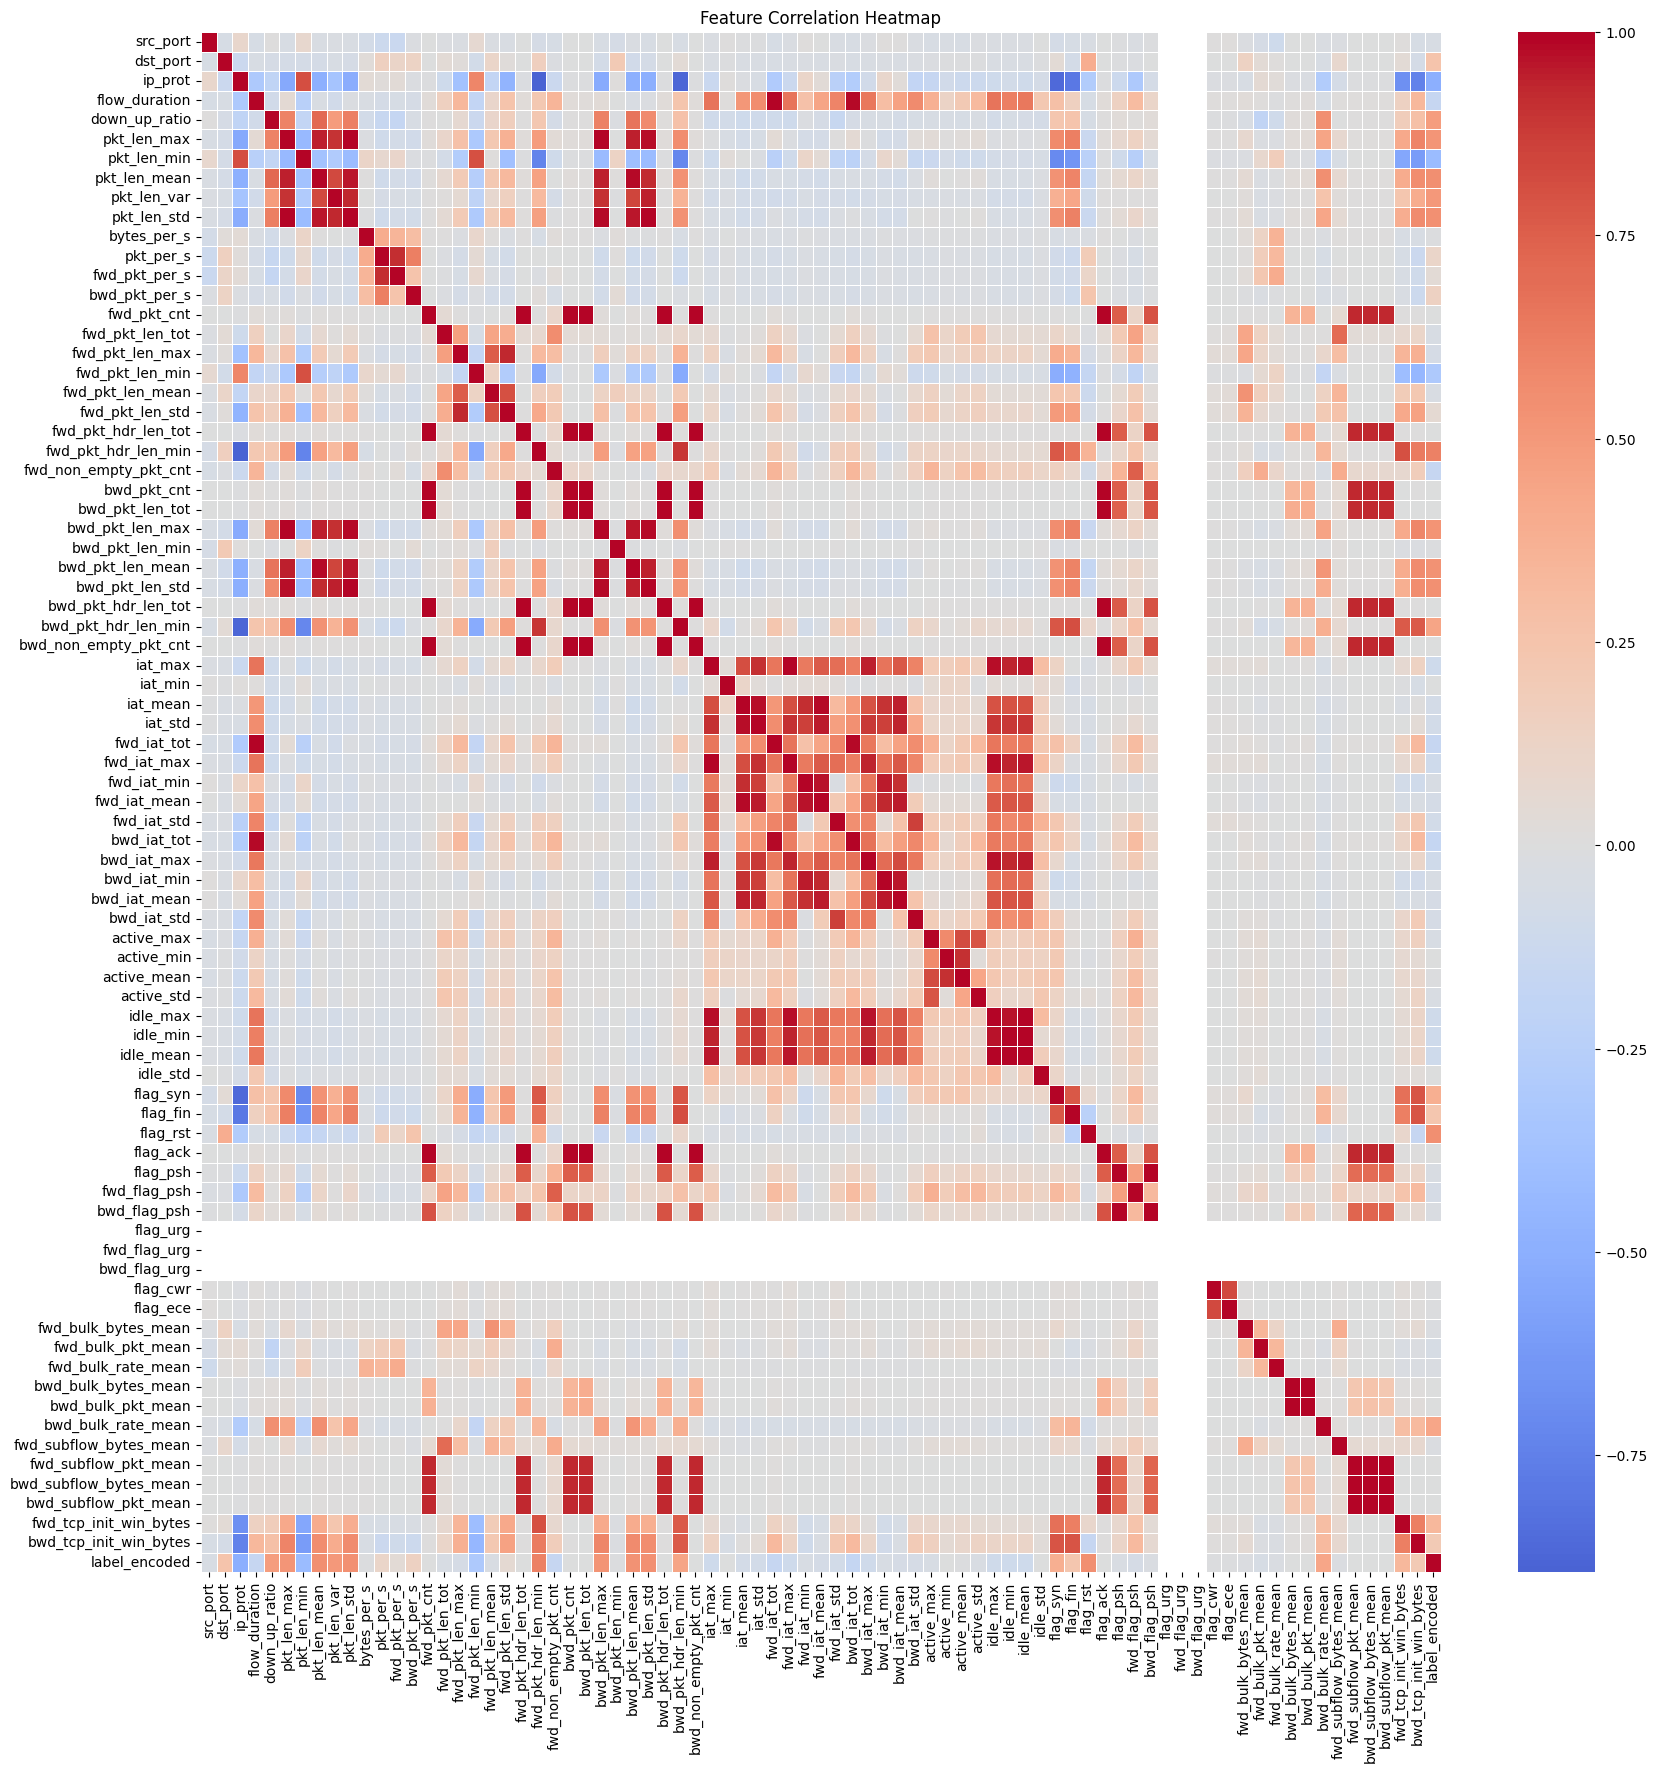

In [34]:
corr_matrix = plot_heatmap(eda_sample_copy)

In [35]:
highly_correlated_rows = drop_highly_correlated_col(corr_matrix=corr_matrix)
print(highly_correlated_rows)

['bwd_iat_mean', 'idle_max', 'fwd_pkt_len_std', 'bwd_subflow_bytes_mean', 'fwd_pkt_hdr_len_tot', 'bwd_pkt_len_mean', 'fwd_subflow_pkt_mean', 'fwd_iat_tot', 'iat_std', 'pkt_len_std', 'bwd_subflow_pkt_mean', 'idle_min', 'bwd_bulk_pkt_mean', 'bwd_flag_psh', 'bwd_non_empty_pkt_cnt', 'bwd_pkt_len_std', 'bwd_pkt_len_tot', 'bwd_pkt_len_max', 'bwd_iat_tot', 'flag_ack', 'pkt_len_mean', 'fwd_iat_max', 'bwd_pkt_hdr_len_tot', 'bwd_iat_min', 'bwd_pkt_cnt', 'fwd_iat_mean', 'idle_mean', 'bwd_iat_max']


In [36]:
eda_sample.drop(columns=highly_correlated_rows,axis=1,inplace=True)
eda_sample.shape

(658877, 51)

### Checking and handling nan values

In [37]:
(eda_sample.isna().sum() / len(eda_sample)) * 100

src_port                  0.0
dst_port                  0.0
ip_prot                   0.0
flow_duration             0.0
down_up_ratio             0.0
pkt_len_max               0.0
pkt_len_min               0.0
pkt_len_var               0.0
bytes_per_s               0.0
pkt_per_s                 0.0
fwd_pkt_per_s             0.0
bwd_pkt_per_s             0.0
fwd_pkt_cnt               0.0
fwd_pkt_len_tot           0.0
fwd_pkt_len_max           0.0
fwd_pkt_len_min           0.0
fwd_pkt_len_mean          0.0
fwd_pkt_hdr_len_min       0.0
fwd_non_empty_pkt_cnt     0.0
bwd_pkt_len_min           0.0
bwd_pkt_hdr_len_min       0.0
iat_max                   0.0
iat_min                   0.0
iat_mean                  0.0
fwd_iat_min               0.0
fwd_iat_std               0.0
bwd_iat_std               0.0
active_max                0.0
active_min                0.0
active_mean               0.0
active_std                0.0
idle_std                  0.0
flag_syn                  0.0
flag_fin  

Since value of na value is so less(less than 5% of data). Therefore, we will drop na values

In [38]:
eda_sample.dropna(inplace=True)
eda_sample.shape

(658877, 51)

### Important Features

['src_port', 'dst_port', 'ip_prot', 'flow_duration', 'down_up_ratio', 'pkt_len_max', 'pkt_len_min', 'pkt_len_var', 'bytes_per_s', 'pkt_per_s', 'fwd_pkt_per_s', 'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_len_tot', 'fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_hdr_len_min', 'fwd_non_empty_pkt_cnt', 'bwd_pkt_len_min', 'bwd_pkt_hdr_len_min', 'iat_max', 'iat_min', 'iat_mean', 'fwd_iat_min', 'fwd_iat_std', 'bwd_iat_std', 'active_max', 'active_min', 'active_mean', 'active_std', 'idle_std', 'flag_syn', 'flag_fin', 'flag_rst', 'flag_psh', 'fwd_flag_psh', 'flag_urg', 'fwd_flag_urg', 'bwd_flag_urg', 'flag_cwr', 'flag_ece', 'fwd_bulk_bytes_mean', 'fwd_bulk_pkt_mean', 'fwd_bulk_rate_mean', 'bwd_bulk_bytes_mean', 'bwd_bulk_rate_mean', 'fwd_subflow_bytes_mean', 'fwd_tcp_init_win_bytes', 'bwd_tcp_init_win_bytes'] 
 ['label']
train f1 scor: 1.0

Classification Report:

              precision    recall  f1-score   support

      benign       1.00      1.00      1.00    155385
       

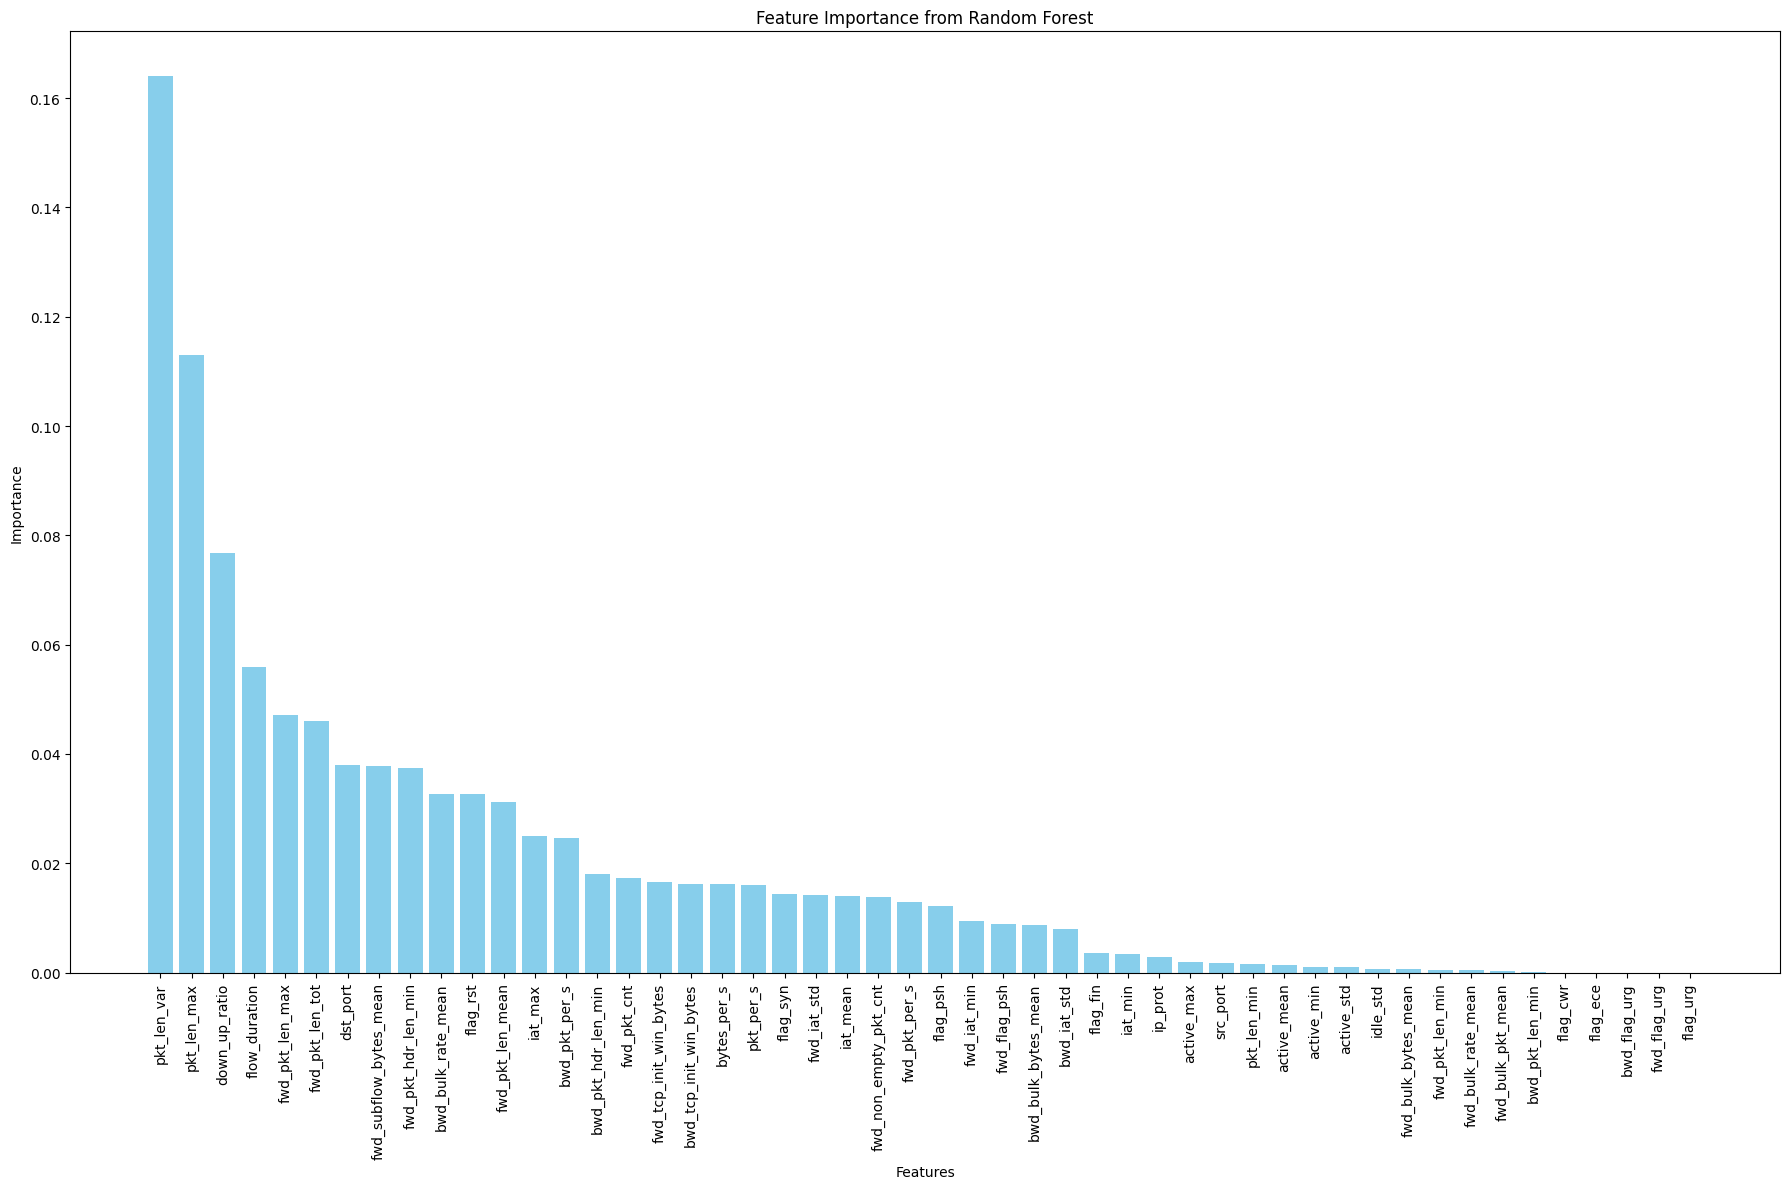

[[155368      1      0      0     14      1      1]
 [     0     57      0      0      0      0      0]
 [     0      0    836      0      0      0      0]
 [     0      0      0   7498      0      0      0]
 [    10      0      0      0  21143      0      2]
 [     2      0      0      0      1  12486      0]
 [     4      0      0      0      0      0    240]] ['benign' 'bot' 'brute_force' 'ddos' 'dos' 'portscan' 'web_attacks']


In [47]:
top_important_features,rf_model = important_features(eda_sample)

In [34]:
print(top_important_features)

                   Feature  Importance
7              pkt_len_var    0.146007
5              pkt_len_max    0.118159
13         fwd_pkt_len_tot    0.065695
14         fwd_pkt_len_max    0.058432
16        fwd_pkt_len_mean    0.047559
34                flag_rst    0.045613
3            flow_duration    0.041278
47  fwd_subflow_bytes_mean    0.041108
4            down_up_ratio    0.038836
1                 dst_port    0.032918
21                 iat_max    0.031265
46      bwd_bulk_rate_mean    0.028985
11           bwd_pkt_per_s    0.028973
17     fwd_pkt_hdr_len_min    0.026156
8              bytes_per_s    0.026120
50  bwd_tcp_init_win_bytes    0.022485
10           fwd_pkt_per_s    0.021027
23                iat_mean    0.020487
18   fwd_non_empty_pkt_cnt    0.019910
49  fwd_tcp_init_win_bytes    0.019348
9                pkt_per_s    0.016694
20     bwd_pkt_hdr_len_min    0.015365
25             fwd_iat_std    0.009451
32                flag_syn    0.009155
35                flag_ps

In [48]:
def vectorized_cumsum(top_features: pd.DataFrame):
    # .cumsum() calculates the running tally for the whole column instantly
    running_tally = top_features['Importance'].cumsum()
    
    # We check which rows are under 0.95 (returns True/False)
    # .sum() counts all the True values (each True = 1)
    # We add 1 to include the specific feature that pushes it over the 0.95 line
    feature_no = (running_tally < 0.96).sum() + 1 
    
    print(feature_no)

In [49]:
vectorized_cumsum(top_important_features)

28


**Evaluation is performed on temporally separated test data (Friday), which reflects real-world distribution where not all attack types occur simultaneously**

In [55]:
test_df = pd.read_csv("../Artifacts/data_ingestion/ingested/test.csv")
test_df = test_df.drop(columns=highly_correlated_rows,axis=1)
test_df = drop_col(test_df)
test_df.columns = preprocess_column_name(test_df)

X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

y_pred = rf_model.predict(X_test)
test_f1_score = f1_score(y_test,y_pred,average='macro')
test_classification_metrics = classification_report(y_true=y_test,y_pred=y_pred)
print('test_f1_score:',test_f1_score)
print(test_classification_metrics)

c:\Users\priyanshu\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\priyanshu\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


test_f1_score: 0.6666473279963027
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00    100804
         bot       1.00      1.00      1.00       257
        ddos       1.00      1.00      1.00     33200
         dos       0.00      0.00      0.00         0
    portscan       1.00      1.00      1.00     56033
 web_attacks       0.00      0.00      0.00         0

    accuracy                           1.00    190294
   macro avg       0.67      0.67      0.67    190294
weighted avg       1.00      1.00      1.00    190294



c:\Users\priyanshu\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [56]:
test_df['label'].value_counts()

label
benign      100804
portscan     56033
ddos         33200
bot            257
Name: count, dtype: int64

# Saving 28 Important features to top_features.yaml
Early During CIC-IDS2017, we have choosen top 20 features which may have led to small dataset for model to understand pattern and train on, making model difficult to predict minority class. (which might have contribute to very little part in failure among the major flaw in dataset, CICFlowmeter processing the packets and making the CIC dataset, Tool mismatch)
### All the 78 features will be stored in schema.yaml

In [57]:
# 1. Grab your top 20 features (assuming 'Feature' column holds the original names)
imp_features = top_important_features['Feature'].head(28).tolist()

# 2. Build the dictionary using the original dataset to get the correct data types
top_28_features = {feature: str(eda_sample[feature].dtype) for feature in imp_features}

print(top_28_features,len(top_28_features))

{'pkt_len_var': 'float64', 'pkt_len_max': 'float64', 'down_up_ratio': 'float64', 'flow_duration': 'int64', 'fwd_pkt_len_max': 'float64', 'fwd_pkt_len_tot': 'int64', 'dst_port': 'int64', 'fwd_subflow_bytes_mean': 'float64', 'fwd_pkt_hdr_len_min': 'int64', 'bwd_bulk_rate_mean': 'float64', 'flag_rst': 'int64', 'fwd_pkt_len_mean': 'float64', 'iat_max': 'float64', 'bwd_pkt_per_s': 'float64', 'bwd_pkt_hdr_len_min': 'int64', 'fwd_pkt_cnt': 'int64', 'fwd_tcp_init_win_bytes': 'int64', 'bwd_tcp_init_win_bytes': 'int64', 'bytes_per_s': 'float64', 'pkt_per_s': 'float64', 'flag_syn': 'int64', 'fwd_iat_std': 'float64', 'iat_mean': 'float64', 'fwd_non_empty_pkt_cnt': 'int64', 'fwd_pkt_per_s': 'float64', 'flag_psh': 'int64', 'fwd_iat_min': 'float64', 'fwd_flag_psh': 'int64'} 28


### Storing important features in top_features.yaml

In [58]:
write_yaml_file(file_path="../data_schema/top_features.yaml",content=top_28_features, replace=True)

### Storing all the 78 features and 1 label in schema.yaml

In [47]:
test_df = pd.read_csv("../Artifacts/data_ingestion/ingested/test.csv")
test_df_col = test_df.columns
schema_dict = {feature: str(test_df[feature].dtype) for feature in test_df_col}
print(len(schema_dict))

83


In [48]:
write_yaml_file(file_path="../data_schema/schema.yaml",content=schema_dict, replace=True)